# START HERE: what this EDA is about (read before other notebooks)

This notebook is for the group meeting. It explains words, geography, and what each other notebook does.

**Project in one sentence:** Zero Hunger Lab / ZOA want to understand river floods in South Sudan so they can do anticipatory action (help before the flood hits), especially for local farmers and inhabitants.

**Our EDA job:** describe the data honestly (where water is, who/what is under it, what comes before floods). Not build the final forecast yet.


## Glossary (say these out loud)

| Word | Meaning |
|------|---------|
| **Hazard** | Where/when water is detected (flood masks) |
| **Exposure** | Who/what is in that place (people, crops, cattle, roads, clinics) |
| **Impact** | What bad thing happens (food insecurity IPC, lost access, damage). We often only have proxies. |
| **Driver / lead time** | Signals that come before flooding (rain, lake levels, discharge) so you might prepare early |
| **AA** | Anticipatory Action = act before impact (cash, sandbags, early harvest) |
| **Unusual flood** | NASA label: that pixel floods less often than the usual seasonal pattern. NOT "more severe". |
| **Recurring flood** | NASA label: that pixel floods often in that calendar month across years (e.g. wetlands) |
| **bbox** | Bounding box = rectangle on the map defined by min/max lat and lon. Fast filter before exact polygons. |
| **Parquet** | File format for big tables (like a compressed CSV). Flood masks are many parquet files. |
| **Pixel / cell** | One small square on a raster grid (~250m for floods, ~100m for population, ~500m for crop) |
| **Raster / GeoTIFF** | Image-like grid where each cell has a number (population, crop %) |
| **admin0 / 1 / 2 / 3** | Country / state / county / payam boundary polygons |
| **Grazing land / rangeland** | Grass/shrub land used for livestock (ASAP rangeland mask), not cropland fields |
| **IPC** | Food insecurity phases. Phase 3+ = crisis or worse |
| **WorldPop** | Modelled number of people per ~100m cell |
| **ASAP crop %** | 0-100 how much of a ~500m cell is cropland (static map) |


## South Sudan geography we use

There are **10 states** (admin1) and **79 counties** (admin2), plus Abyei. Payams (admin3) are smaller units under counties.

We first rank **all counties**. Then we zoom to **Jonglei, Unity, and Upper Nile** because unusual water and OCHA/Yassin briefing concentrate there (Sudd, Bentiu/Rubkona, Malakal / Panyikang). Other states can still flood. The old two-state-only EDA missed Unity (west of lon 30.5).


## FAQ you will get asked

**What is 100205?**
A Dartmouth Flood Observatory **river discharge** station (their area id `100205`, station nr 334). It is a modelled/reconstructed daily flow in m3/s, not a flood map. The Excel lists it twice (South Sudan and Sudan) at the **same coordinates**. It is the only station in this zip that sits inside South Sudan. The others are upstream/downstream in Sudan or one in Ethiopia.

**Where is the gauge?**
About **lat 9.6, lon 31.6**, White Nile at **Malakal** (Upper Nile). That is why we compare it more to Upper Nile unusual water than to Jonglei/Sudd.

**Why Jonglei, Unity, Upper Nile?**
Not because the official brief says only White Nile. We rank all counties first. Those three states carry most unusual water here, and they match the team briefing (Jonglei Sudd, Unity/Rubkona, Upper Nile/Panyikang/Malakal). The old bbox starting at lon 30.5 missed Unity.

**Why Lake Albert?**
We are **not** Albert-only. Victoria and Kyoga are the big upstream lakes on the White Nile (already in `drivers_leadtime.ipynb`). Albert is the third Hydroweb lake in the zip, also Nile system. Wei plotted Albert vs flood counts; we joined it to *our* unusual series so the group has one story. Physical flood water in this region is a mix of: local rain/runoff, river discharge, and water released/stored in those lakes, plus Sudd drainage (no extra dataset for that last one).


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

%matplotlib inline

# notebooks are run from group_repo. if you opened from eda/, go one folder up
ROOT = Path(".").resolve()
if not (ROOT / "raw_data").exists():
    ROOT = Path("..").resolve()
DATA = ROOT / "raw_data"
OUT = ROOT / "eda" / "outputs" / "guide"
OUT.mkdir(parents=True, exist_ok=True)

# admin0 = country, admin1 = states, admin2 = counties
admin0 = gpd.read_file(DATA / "Administrative boundaries" / "ssd_admin0.geojson")
admin1 = gpd.read_file(DATA / "Administrative boundaries" / "ssd_admin1.geojson")
admin2 = gpd.read_file(DATA / "Administrative boundaries" / "ssd_admin2.geojson")

print("States (admin1):")
for s in sorted(admin1["adm1_name"].unique()):
    print("-", s)
print("\nNumber of counties (admin2):", len(admin2))


States (admin1):
- Central Equatoria
- Eastern Equatoria
- Jonglei
- Lakes
- Northern Bahr el Ghazal
- Unity
- Upper Nile
- Warrap
- Western Bahr el Ghazal
- Western Equatoria

Number of counties (admin2): 79


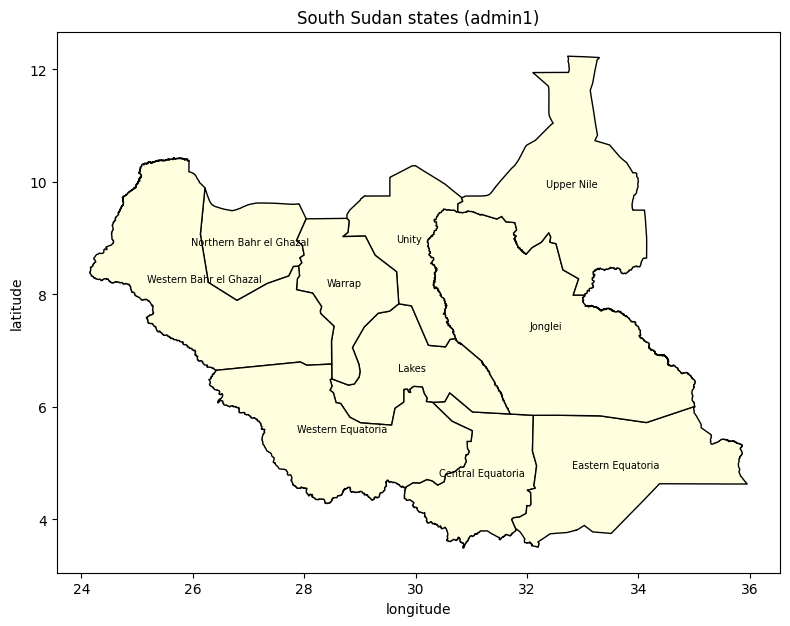

In [2]:
# label at polygon centroid so names sit on the state
fig, ax = plt.subplots(figsize=(8, 8))
admin1.plot(ax=ax, edgecolor="black", facecolor="lightyellow")
admin1.apply(lambda r: ax.annotate(text=r["adm1_name"], xy=r.geometry.centroid.coords[0], ha="center", fontsize=7), axis=1)
ax.set_title("South Sudan states (admin1)")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
fig.tight_layout()
fig.savefig(OUT / "01_all_states.png", dpi=150)
plt.show()


In [3]:
# one row per county so we can list them in the meeting
rows = []
for s in sorted(admin2["adm1_name"].unique()):
    for c in sorted(admin2.loc[admin2["adm1_name"]==s, "adm2_name"].unique()):
        rows.append({"state_admin1": s, "county_admin2": c})
counties = pd.DataFrame(rows)
counties.to_csv(OUT / "all_states_and_counties.csv", index=False)
# we focus on these two states later
display(counties[counties["state_admin1"].isin(["Jonglei", "Unity", "Upper Nile"])])


,state_admin1,county_admin2
15,Jonglei,Akobo
16,Jonglei,Ayod
17,Jonglei,Bor South
18,Jonglei,Canal/Pigi
19,Jonglei,Duk
20,Jonglei,Fangak
21,Jonglei,Nyirol
22,Jonglei,Pibor
23,Jonglei,Pochalla
24,Jonglei,Twic East


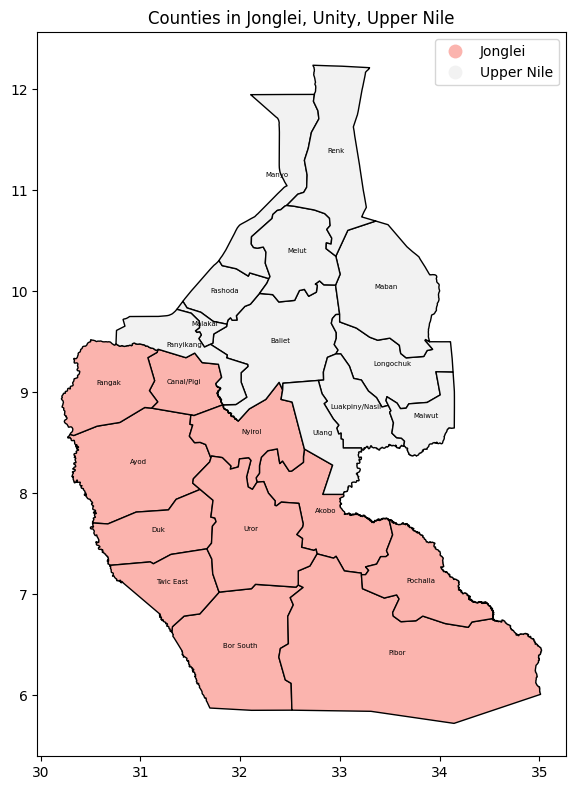

In [4]:
# zoom so county names are readable (the full-country map is too crowded)
focus = admin2[admin2["adm1_name"].isin(["Jonglei", "Upper Nile"])]
fig, ax = plt.subplots(figsize=(9, 8))
focus.plot(ax=ax, column="adm1_name", legend=True, edgecolor="black", cmap="Pastel1")
for _, r in focus.iterrows():
    ax.annotate(r["adm2_name"], xy=r.geometry.centroid.coords[0], ha="center", fontsize=5)
ax.set_title("Counties in Jonglei, Unity, Upper Nile")
fig.tight_layout()
fig.savefig(OUT / "02_jonglei_upper_nile_counties.png", dpi=150)
plt.show()


## What is a bbox? (example)

A **bounding box** is the smallest axis-aligned rectangle that covers an area.

Example for Jonglei-ish window we used in code:
`lat 5.5 to 8.5`, `lon 30.5 to 34.5`

Why use it?
1. Fast: filter millions of flood rows before expensive polygon joins
2. Simple for early EDA

Limit: the rectangle can include bits of neighboring states. For "official" local results we then join to admin2/admin3 polygons.


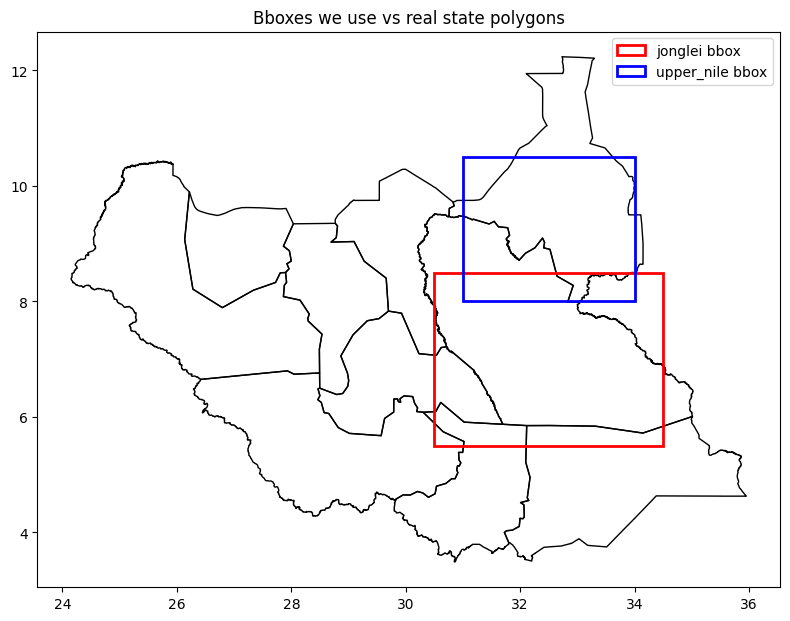

In [5]:
# these numbers are a rectangle, not the official state border
jonglei_bbox = {"lat_min": 5.5, "lat_max": 8.5, "lon_min": 30.5, "lon_max": 34.5}
upper_bbox = {"lat_min": 8.0, "lat_max": 10.5, "lon_min": 31.0, "lon_max": 34.0}

fig, ax = plt.subplots(figsize=(8, 8))
admin1.plot(ax=ax, facecolor="none", edgecolor="black")
from matplotlib.patches import Rectangle
ax.add_patch(Rectangle((jonglei_bbox["lon_min"], jonglei_bbox["lat_min"]),
                       jonglei_bbox["lon_max"]-jonglei_bbox["lon_min"],
                       jonglei_bbox["lat_max"]-jonglei_bbox["lat_min"],
                       fill=False, edgecolor="red", linewidth=2, label="jonglei bbox"))
ax.add_patch(Rectangle((upper_bbox["lon_min"], upper_bbox["lat_min"]),
                       upper_bbox["lon_max"]-upper_bbox["lon_min"],
                       upper_bbox["lat_max"]-upper_bbox["lat_min"],
                       fill=False, edgecolor="blue", linewidth=2, label="upper_nile bbox"))
ax.legend()
ax.set_title("Bboxes we use vs real state polygons")
fig.tight_layout()
fig.savefig(OUT / "03_bboxes_vs_states.png", dpi=150)
plt.show()


## Flood data and parquet (Wei notebook)

Flood masks are **not** one big map per day of the whole country.
Each row in a parquet file = one flooded pixel on one date.

Files look like:
`raw_data/flood_masks/compact_unusual/flood_events_h21v08_2023.parquet`

- `compact_unusual` / `compact_recurring` = two folders
- `h20v08` / `h21v08` = two satellite tiles that together cover South Sudan
- year in the filename

Wei's script `eda/flood_masks_eda.py` opens those parquet files and makes yearly/monthly/spatial summaries.
We did **not** convert them to other parquet caches for the group notebooks; we read the course files directly.


In [6]:
# one row = one flooded pixel on one day. this file is only one tile and one year
sample_path = DATA / "flood_masks" / "compact_unusual" / "flood_events_h21v08_2023.parquet"
df = pd.read_parquet(sample_path, columns=["date", "lat", "lon", "tile"])
print("rows in this one file:", len(df))
print("columns:", df.columns.tolist())
display(df.head())
# date is stored as category/string in some files; convert before min/max
dates = pd.to_datetime(df["date"].astype(str))
print("date range:", dates.min(), "to", dates.max())


rows in this one file: 5502608
columns: ['date', 'lat', 'lon', 'tile']


,date,lat,lon,tile
0,2023-01-02,9.746875,37.236458,h21v08
1,2023-01-02,9.686459,30.561459,h21v08
2,2023-01-02,9.686459,30.563541,h21v08
3,2023-01-02,9.684375,30.563541,h21v08
4,2023-01-02,9.684375,30.565624,h21v08


date range: 2023-01-02 00:00:00 to 2023-12-31 00:00:00


## Reading order (same as the meeting)

Full script: `eda/talk/MEETING_SCRIPT.md`.

1. **This guide** - words + maps
2. **Wei** `flood_masks_eda.py` - hazard inventory
3. `admin_ipc.ipynb` - all 79 counties first, then Unity + Jonglei + Upper Nile + IPC
4. `exposure_locals.ipynb` - people, crop, rangeland, cattle
5. `admin3_payams.ipynb` - payam hotspots (no IPC here)
6. `drivers_leadtime.ipynb` - rain, lakes, gauge 100205
7. `extra_datasets.ipynb` / `osm_malakal.ipynb` - only if asked


## What to say in the meeting

Use `eda/talk/MEETING_SCRIPT.md`, not this short list.

1. EDA for anticipatory action, not a forecast.
2. Unusual is a NASA rarity label, not severity.
3. Ranked all counties. Unity and Jonglei dominate. Rubkona is top. Old bbox missed Unity.
4. Few people under unusual pixels. Crop ~0. Rangeland high.
5. County/payam shortlist includes Rubkona payams (Budaang) plus Ayod/Fangak names. IPC at state is high; no causality.
6. Lakes (Albert about +0.44) have the right sign. Rain and Malakal gauge 100205 are negative monthly. Lead time in the team briefing is months, not one month.
